In [19]:
import os
import math
import random
import json
import glob

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# --- DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- PATH ---
DATASET_ROOT = r"C:\\Users\\IVAN\\Desktop\\Study\\Mag sem2\\Computer Vision\\HW1\\autoriaNumberplateOcrRu"

# --- TRAIN PARAMS ---
BATCH_SIZE = 16
IMG_HEIGHT = 32
IMG_WIDTH = 256

MAX_EPOCHS = 50
NUM_WORKERS = 0

LR = 1e-4

# --- DATA LIMIT (для отладки) ---
MAX_TRAIN_SAMPLES = 3000
MAX_TEST_SAMPLES = 300

# --- SEED ---
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# --- CUDNN (ускорение + стабильность) ---
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

Using device: cuda


In [20]:
ALPHABET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

blank_idx = 0
char2idx = {c: i + 1 for i, c in enumerate(ALPHABET)}
idx2char = {i + 1: c for i, c in enumerate(ALPHABET)}

vocab_size = len(ALPHABET) + 1


# --- TRANSFORMS ---
train_transforms = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),

    # добавили легкие аугментации
    T.RandomAffine(degrees=2, translate=(0.02, 0.02)),
    T.ColorJitter(contrast=0.2, brightness=0.2),

    T.ToTensor(),
    # УБРАЛИ Normalize
])

test_transforms = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
])


class NumberplateOCRDataset(Dataset):
    def __init__(self, root, split, transforms=None, max_samples=None):
        self.root = root
        self.split = split
        self.transforms = transforms

        ann_dir = os.path.join(root, split, "ann")
        self.ann_paths = glob.glob(os.path.join(ann_dir, "*.json"))
        self.ann_paths.sort()

        if max_samples is not None:
            self.ann_paths = self.ann_paths[:max_samples]

    def __len__(self):
        return len(self.ann_paths)

    # --- ВАЖНО: чистим текст ---
    def normalize_text(self, text):
        text = str(text).upper()

        # убираем всё лишнее
        text = "".join([c for c in text if c in ALPHABET])

        return text

    def encode_text(self, text):
        text = self.normalize_text(text)
        return [char2idx[c] for c in text]

    def __getitem__(self, idx):
        ann_path = self.ann_paths[idx]

        with open(ann_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        name = data["name"]
        raw_text = str(data.get("description", ""))

        text = self.normalize_text(raw_text)

        img_rel = os.path.join(self.split, "img", name + ".png")
        img_path = os.path.join(self.root, img_rel)

        image = Image.open(img_path).convert("RGB")

        if self.transforms is not None:
            image = self.transforms(image)

        label_encoded = self.encode_text(text)

        # --- фильтр пустых ---
        if len(label_encoded) == 0:
            # fallback (редко, но важно)
            label_encoded = [1]  # любой валидный символ

        label = torch.tensor(label_encoded, dtype=torch.long)

        return image, label, text


train_dataset = NumberplateOCRDataset(
    DATASET_ROOT, "train",
    transforms=train_transforms,
    max_samples=MAX_TRAIN_SAMPLES
)

test_dataset = NumberplateOCRDataset(
    DATASET_ROOT, "test",
    transforms=test_transforms,
    max_samples=MAX_TEST_SAMPLES
)


def collate_fn(batch):
    # фильтруем пустые
    batch = [b for b in batch if len(b[1]) > 0]

    images = [b[0] for b in batch]
    labels = [b[1] for b in batch]
    texts = [b[2] for b in batch]

    images = torch.stack(images, dim=0)

    label_lengths = torch.tensor(
        [len(l) for l in labels],
        dtype=torch.long
    )

    targets = torch.cat(labels, dim=0)

    return images, targets, label_lengths, texts


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=True   # ← ВАЖНО для стабильности
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False
)

In [21]:
#!pip install editdistance
import editdistance
import torch.nn.functional as F


# ===================== METRICS =====================

def compute_cer(gt_text: str, pred_text: str) -> float:
    dist = editdistance.eval(gt_text, pred_text)
    return dist / max(len(gt_text), 1)


def decode_sequence(seq):
    result = []
    prev = -1
    for s in seq:
        s = s.item()
        if s != prev and s != blank_idx:
            result.append(idx2char.get(s, ""))
        prev = s
    return "".join(result)


def evaluate_cer(model, loader, max_batches=None):
    model.eval()
    total_cer = 0.0
    total_chars = 0
    correct_chars = 0
    samples_processed = 0

    with torch.no_grad():
        for bi, (images, targets, target_lengths, texts) in enumerate(loader):
            images = images.to(device)

            logits = model(images)                    # (N, T, C)
            pred_indices = logits.argmax(dim=2)       # (N, T) ← индексы предсказанных символов

            for i in range(images.size(0)):
                decoded = decode_sequence(pred_indices[i])   # ✅ i-й пример
                gt = str(texts[i])

                cer = compute_cer(gt, decoded)
                total_cer += cer
                samples_processed += 1

                L = max(len(gt), len(decoded))
                if L > 0:
                    correct_chars += sum(
                        1 for a, b in zip(gt.ljust(L), decoded.ljust(L)) if a == b
                    )
                    total_chars += L

            if max_batches and bi + 1 >= max_batches:
                break

    avg_cer = total_cer / max(1, samples_processed)
    char_accuracy = correct_chars / max(1, total_chars)

    return avg_cer, char_accuracy, samples_processed

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3, stride=1, pad=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, ks, stride, pad, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # --- CNN (бережём ширину) ---
        self.cnn = nn.Sequential(
            ConvBlock(1, 64),
            nn.MaxPool2d(2, 2),          # H/2, W/2

            ConvBlock(64, 128),
            nn.MaxPool2d(2, 2),          # H/4, W/4

            ConvBlock(128, 256),
            ConvBlock(256, 256),
            nn.MaxPool2d((2, 1)),        # H/8, W/4

            ConvBlock(256, 512),
            ConvBlock(512, 512),
            nn.MaxPool2d((2, 1)),        # H/16, W/4

            nn.Conv2d(512, 512, 2, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # Dropout ДО RNN (важнее чем после)
        self.dropout = nn.Dropout(0.3)

        # --- RNN ---
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        # --- CLASSIFIER ---
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # (N, 1, H, W)
        x = self.cnn(x)
        # (N, 512, 1, W')

        x = x.squeeze(2)           # (N, 512, W')
        x = x.permute(0, 2, 1)     # (N, W', 512)

        x = self.dropout(x)        # стабилизация перед RNN

        x, _ = self.lstm(x)        # (N, W', 512)

        x = self.fc(x)             # (N, W', C)

        return x

In [23]:
# ========== 1. Создание модели (используем CRNN из ячейки 5) ==========
model = CRNN(num_classes=vocab_size).to(device)

# ========== 2. Функция потерь и оптимизатор ==========
criterion = nn.CTCLoss(blank=blank_idx, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ========== 3. Обучение ==========
num_epochs = MAX_EPOCHS
for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0

    for images, targets, target_lengths, _ in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)

        # forward
        logits = model(images)                     # (N, T, C)
        log_probs = F.log_softmax(logits, dim=2)   # (N, T, C)
        log_probs = log_probs.permute(1, 0, 2)     # (T, N, C) для CTCLoss

        input_lengths = torch.full(
            (log_probs.size(1),), log_probs.size(0),
            dtype=torch.long, device=device
        )

        loss = criterion(log_probs, targets, input_lengths, target_lengths)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    scheduler.step(avg_loss)

    # Быстрая оценка каждые 10 эпох
    if epoch % 10 == 0:
        cer, char_acc, _ = evaluate_cer(model, test_loader, max_batches=5)
        print(f"Epoch {epoch:3d} | loss: {avg_loss:.4f} | CER: {cer*100:.2f}% | CharAcc: {char_acc*100:.2f}%")
    else:
        print(f"Epoch {epoch:3d} | loss: {avg_loss:.4f}")

print("Обучение завершено.\n")
# === СОХРАНЕНИЕ МОДЕЛИ ===
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'alphabet': ALPHABET,
    'img_height': IMG_HEIGHT,
    'img_width': IMG_WIDTH,
}, "crnn_ocr_license_plate.pth")
print("Модель сохранена в crnn_ocr_license_plate.pth")

# === Финальная оценка (исправленная evaluate_cer) ===
cer, char_acc, _ = evaluate_cer(model, test_loader, max_batches=10)
print(f"Test CER: {cer*100:.2f}% | Test CharAcc: {char_acc*100:.2f}%")

Epoch   1 | loss: 4.6423
Epoch   2 | loss: 2.4506
Epoch   3 | loss: 1.7171
Epoch   4 | loss: 0.4440
Epoch   5 | loss: 0.0976
Epoch   6 | loss: 0.0537
Epoch   7 | loss: 0.0402
Epoch   8 | loss: 0.0316
Epoch   9 | loss: 0.0199
Epoch  10 | loss: 0.0171 | CER: 1.61% | CharAcc: 96.75%
Epoch  11 | loss: 0.0181
Epoch  12 | loss: 0.0142
Epoch  13 | loss: 0.0165
Epoch  14 | loss: 0.0093
Epoch  15 | loss: 0.0088
Epoch  16 | loss: 0.0114
Epoch  17 | loss: 0.0124
Epoch  18 | loss: 0.0165
Epoch  19 | loss: 0.0055
Epoch  20 | loss: 0.0030 | CER: 1.30% | CharAcc: 98.08%
Epoch  21 | loss: 0.0119
Epoch  22 | loss: 0.0162
Epoch  23 | loss: 0.0119
Epoch  24 | loss: 0.0110
Epoch  25 | loss: 0.0124
Epoch  26 | loss: 0.0045
Epoch  27 | loss: 0.0028
Epoch  28 | loss: 0.0014
Epoch  29 | loss: 0.0012
Epoch  30 | loss: 0.0027 | CER: 1.01% | CharAcc: 97.63%
Epoch  31 | loss: 0.0026
Epoch  32 | loss: 0.0022
Epoch  33 | loss: 0.0010
Epoch  34 | loss: 0.0016
Epoch  35 | loss: 0.0033
Epoch  36 | loss: 0.0027
Epoch  

C:\Users\IVAN\AppData\Local\Temp\ipykernel_4508\3546924454.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("crnn_ocr_license_plate.pth", map_loca

Модель загружена


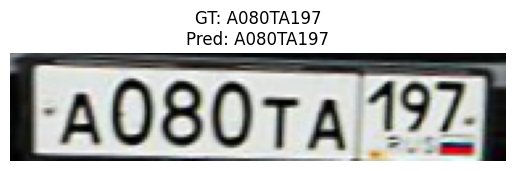

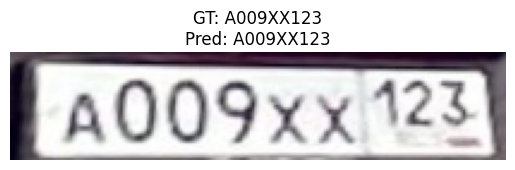

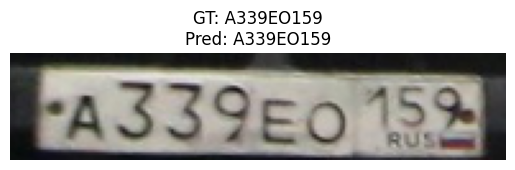

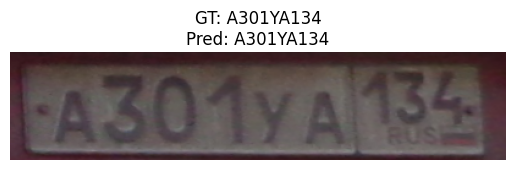

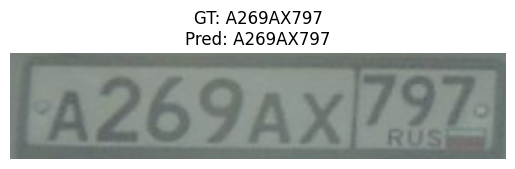

In [24]:
import matplotlib.pyplot as plt
from PIL import Image

# ========== Загрузка модели ==========
checkpoint = torch.load("crnn_ocr_license_plate.pth", map_location=device)

# Если алфавит сохранён, можно восстановить (иначе используем тот же из глобальной области)
loaded_alphabet = checkpoint.get('alphabet', ALPHABET)
char2idx_load = {c: i + 1 for i, c in enumerate(loaded_alphabet)}
idx2char_load = {i + 1: c for i, c in enumerate(loaded_alphabet)}
blank_idx = 0
vocab_size = len(loaded_alphabet) + 1

# Создаём модель и загружаем веса
model = CRNN(num_classes=vocab_size).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Модель загружена")

# ========== Функция для инференса на одном изображении ==========
def predict_image(img_path):
    image = Image.open(img_path).convert("RGB")
    img_tensor = test_transforms(image).unsqueeze(0).to(device)  # (1, 1, H, W)

    with torch.no_grad():
        logits = model(img_tensor)               # (1, T, C)
        pred_indices = logits.argmax(dim=2)[0]   # (T,)
        decoded = decode_sequence(pred_indices)  # строка
    return decoded

# ========== Демонстрация на 5 случайных тестовых примерах ==========
num_examples = 5
indices = random.sample(range(len(test_dataset)), min(num_examples, len(test_dataset)))

for idx in indices:
    ann_path = test_dataset.ann_paths[idx]
    with open(ann_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    img_path = os.path.join(DATASET_ROOT, "test", "img", data["name"] + ".png")

    predicted = predict_image(img_path)
    gt = test_dataset.normalize_text(data.get("description", ""))

    # Отображаем картинку и текст
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"GT: {gt}\nPred: {predicted}")
    plt.axis("off")
    plt.show()

In [ ]:
import pandas as pd

# ---------- БАЗОВЫЙ КОНФИГ ----------
base_config = {
    'seed': 42,
    'img_height': 32,
    'img_width': 256,
    'epochs': 15,
    'batch_size': 16,
    'lr': 1e-4,
    'cnn_channels': [64, 128, 256, 512],
    'augment': True,
    'use_scheduler': True
}

# ---------- НАБОР КОНФИГУРАЦИЙ (все рабочие) ----------
experiments = []

# 1. Размер изображения
config1 = base_config.copy()
config1['img_width'] = 128
experiments.append(("Узкое изображение 32x128", config1))

config2 = base_config.copy()
config2['img_width'] = 320
experiments.append(("Широкое изображение 32x320", config2))

# 2. Глубина / ширина CNN (меняем количество каналов, не добавляя новых блоков)
config3 = base_config.copy()
config3['cnn_channels'] = [32, 64, 128, 256]          # легче
experiments.append(("Облегчённый CNN [32,64,128,256]", config3))

config4 = base_config.copy()
config4['cnn_channels'] = [128, 256, 512, 512]        # шире, но всё ещё 4 блока
experiments.append(("Широкий CNN [128,256,512,512]", config4))

# 3. Без планировщика
config5 = base_config.copy()
config5['use_scheduler'] = False
experiments.append(("Без планировщика LR", config5))

# 4. Без аугментаций
config6 = base_config.copy()
config6['augment'] = False
experiments.append(("Без аугментаций", config6))

# ---------- ЗАПУСК ВСЕХ ЭКСПЕРИМЕНТОВ ----------
results = []

for name, cfg in experiments:
    print(f"\n{'='*60}")
    print(f"ЗАПУСК: {name}")
    print(f"Конфигурация: {cfg}\n")
    cer, char_acc, model = run_experiment(cfg)
    results.append({
        "Эксперимент": name,
        "CER, %": round(cer*100, 2),
        "CharAcc, %": round(char_acc*100, 2),
        "img_size": f"{cfg['img_height']}x{cfg['img_width']}",
        "cnn": cfg['cnn_channels'],
        "scheduler": cfg['use_scheduler'],
        "augment": cfg['augment']
    })
    print(f"ИТОГ: CER={cer*100:.2f}% | CharAcc={char_acc*100:.2f}%")

# ---------- ТАБЛИЦА РЕЗУЛЬТАТОВ ----------
df = pd.DataFrame(results)
print("\n\n=== СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ ===")
print(df.to_string(index=False))


ЗАПУСК: Узкое изображение 32x128
Конфигурация: {'seed': 42, 'img_height': 32, 'img_width': 128, 'epochs': 15, 'batch_size': 16, 'lr': 0.0001, 'cnn_channels': [64, 128, 256, 512], 'augment': True, 'use_scheduler': True}

Epoch   1/15 | loss: 3.3315
Epoch   2/15 | loss: 2.4491
Epoch   3/15 | loss: 2.1397
Epoch   4/15 | loss: 1.5803
Epoch   5/15 | loss: 0.6258
Epoch   6/15 | loss: 0.1797
Epoch   7/15 | loss: 0.0863
Epoch   8/15 | loss: 0.0576
Epoch   9/15 | loss: 0.0411
Epoch  10/15 | loss: 0.0283
Epoch  11/15 | loss: 0.0251
Epoch  12/15 | loss: 0.0247
Epoch  13/15 | loss: 0.0185
Epoch  14/15 | loss: 0.0142
Epoch  15/15 | loss: 0.0166

=== RESULT ===
CER: 90.98%
Char Acc: 5.61%
ИТОГ: CER=90.98% | CharAcc=5.61%

ЗАПУСК: Широкое изображение 32x320
Конфигурация: {'seed': 42, 'img_height': 32, 'img_width': 320, 'epochs': 15, 'batch_size': 16, 'lr': 0.0001, 'cnn_channels': [64, 128, 256, 512], 'augment': True, 'use_scheduler': True}

Epoch   1/15 | loss: 4.3784
Epoch   2/15 | loss: 2.5726
Epo